In [1]:
5+5

10

In [2]:
import os
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from langchain.chat_models import init_chat_model

In [3]:



tool = TavilySearch(max_results=2)


In [4]:
def multiply(a:int,b:int)-> int:
    """Multiply a and b"""
    return a*b

In [5]:
tools = [tool,multiply]

In [6]:
llm = init_chat_model("groq:llama-3.1-8b-instant")

In [7]:
llm_with_tools = llm.bind_tools(tools)

In [8]:
# shared memory || shared state
from typing import Annotated, TypedDict
from langgraph.graph import add_messages


class State(TypedDict):
    messages:Annotated[list,add_messages]

In [9]:
# Node creation
def tool_calling_llm(state:State):
    return{
        "messages":[llm_with_tools.invoke(state["messages"])] # need to ask ([state["message"]])
    }


In [22]:
# create graph
from langgraph.graph import StateGraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image,display



builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",tools_condition
)

builder.add_edge("tools",END)
graph = builder.compile()




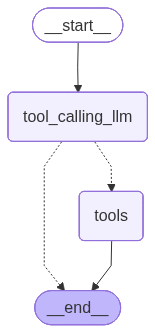

In [23]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
graph.invoke({"messages":(["what is recent ai news"])})

{'messages': [HumanMessage(content='what is recent ai news', additional_kwargs={}, response_metadata={}, id='148ae64b-567b-4f04-878e-fe76196ee7c0'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '1bh9emn15', 'function': {'arguments': '{"query":"recent AI news","search_depth":"advanced","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 1740, 'total_tokens': 1778, 'completion_time': 0.07251195, 'completion_tokens_details': None, 'prompt_time': 0.172473098, 'prompt_tokens_details': None, 'queue_time': 0.107277985, 'total_time': 0.244985048}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4b15-e52c-7c92-b548-0de9ce7c2c2c-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'search_depth'

In [25]:
responce = graph.invoke({
    "messages" : (["what is multiplication of 5 and 5"])
})

In [15]:
responce["messages"][-1].content

'The result of multiplying 5 and 5 is 25.'

In [26]:
responce = graph.invoke({
    "messages":(["what is recent ai news and 5 multiply by 10"])
})



In [17]:
### React Agent Architecture

In [27]:

for m in responce['messages']:
    m.pretty_print()

================================ Human Message =================================

what is recent ai news and 5 multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (jvbaaj5r8)
 Call ID: jvbaaj5r8
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (h2wgaptep)
 Call ID: h2wgaptep
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/05/21/ai-news-cycle-openai-anthropic-spacex", "title": "Two hours that changed AI - Axios", "score": 0.99793327, "published_date": "Thu, 21 May 2026 09:20:05 GMT", "content": "# Two hours that changed AI. Over the course of two hours Wednesday afternoon, the AI industry produced an extraordinary stream of headlines mapping out the vast architecture of it

In [28]:
responce = graph.invoke({
    "messages":(["Hello My Name is Mohit"])
})

for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello My Name is Mohit
================================== Ai Message ==================================

Nice to meet you, Mohit. What brings you here today?


In [29]:
responce = graph.invoke({
    "messages":(["what is my name"])
})

for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is my name
================================== Ai Message ==================================

I don't know your name.
